In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from saidownscale import downscaling_utils, run_bcsd

# 0. Get data

In [2]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [3]:
dict_all_windowed = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

dict_all_not_windowed = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.20 seconds
Subset time: 0.00 seconds
Loaded data: 1.00 seconds
Subset time: 0.00 seconds


### Subset data to demo region

In [4]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'Finland'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
country_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = country_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [6]:
for key in dict_all_windowed:
    dict_all_windowed[key] = downscaling_utils.subset_space(
        dict_all_windowed[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
    )

for key in dict_all_not_windowed:
    dict_all_not_windowed[key] = downscaling_utils.subset_space(
        dict_all_not_windowed[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
    )

# 1. Preprocess data

In [7]:
RECHUNK_WORKFLOW = True  # flag: whether to rechunk data depending on the step
VERBOSE = True

In [9]:
dict_all_windowed = run_bcsd.preprocess_data(
    dict_all_windowed,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
)

Rechunked obs to full space: 2.77 seconds
Interpolated obs to coarse grid: 53.82 seconds
Detrended data: 8.30 seconds


In [10]:
dict_all_not_windowed = run_bcsd.preprocess_data(
    dict_all_not_windowed,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
)

Rechunked obs to full space: 3.61 seconds
Interpolated obs to coarse grid: 52.03 seconds
Detrended data: 8.54 seconds


# 2. Bias correct with quantile mapping

In [11]:
dict_all_windowed = run_bcsd.bias_correct(
    dict_all=dict_all_windowed,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
    do_windowing=True,
)

/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
  0%|          | 0/180 [00:00<?, ?it/s]/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
100%|██████████| 180/180 [00:37<00:00,  4.83it/s]
/op

Quantile mapped historical: 38.23 seconds


100%|██████████| 180/180 [00:52<00:00,  3.42it/s]

Quantile mapped future: 53.22 seconds
Added back trend: 0.01 seconds


In [12]:
dict_all_not_windowed = run_bcsd.bias_correct(
    dict_all=dict_all_not_windowed,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=True,
    do_windowing=False,
)

/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains inf or nan values. Not all debiasers support missing values and their presence might lead to infs or nans inside of the debiased values. Consider infilling the missing values.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
100%|██████████| 180/180 [00:00<00:00, 646.81it/s]
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully
  self._check_output(output)


Quantile mapped historical: 1.44 seconds


100%|██████████| 180/180 [00:00<00:00, 319.24it/s]

Quantile mapped future: 1.09 seconds
Added back trend: 0.01 seconds


# Examine influence of detrending at a single point (before doing the downscaling step)

In [13]:
xind = 8
yind = 8

In [15]:
scenario = "scenario"
output_windowed = dict_all_windowed[scenario + "_debiased"]
output_not_windowed = dict_all_not_windowed[scenario + "_debiased"]

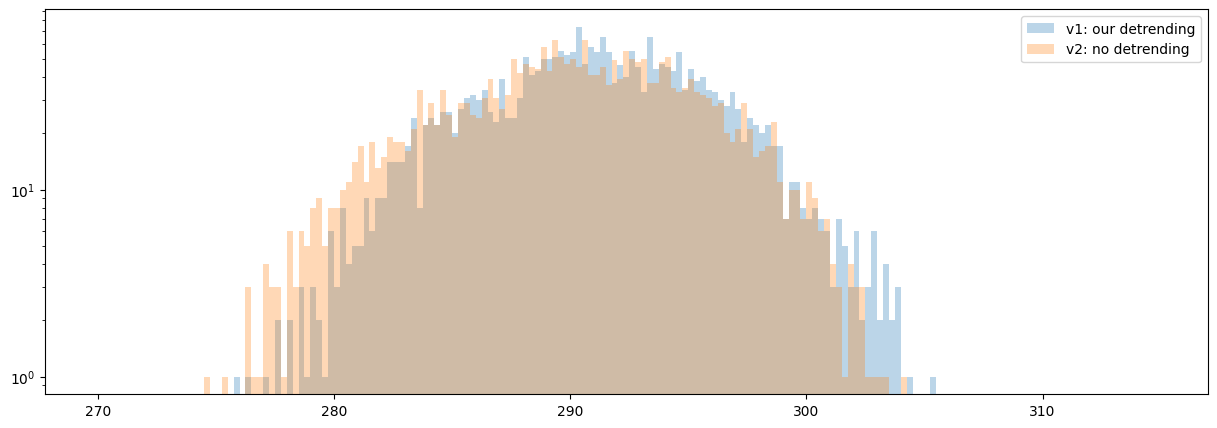

In [16]:
plt.figure(figsize=(15, 5))
plt.hist(
    output_windowed.where(output_windowed["time.month"] == 6)[:, xind, yind],
    bins=np.arange(270, 315, 0.25),
    alpha=0.3,
    label="v1: our detrending",
)
plt.hist(
    output_not_windowed.where(output_not_windowed["time.month"] == 6)[:, xind, yind],
    alpha=0.3,
    bins=np.arange(270, 315, 0.25),
    label="v2: no detrending",
)
plt.yscale("log")
plt.legend()

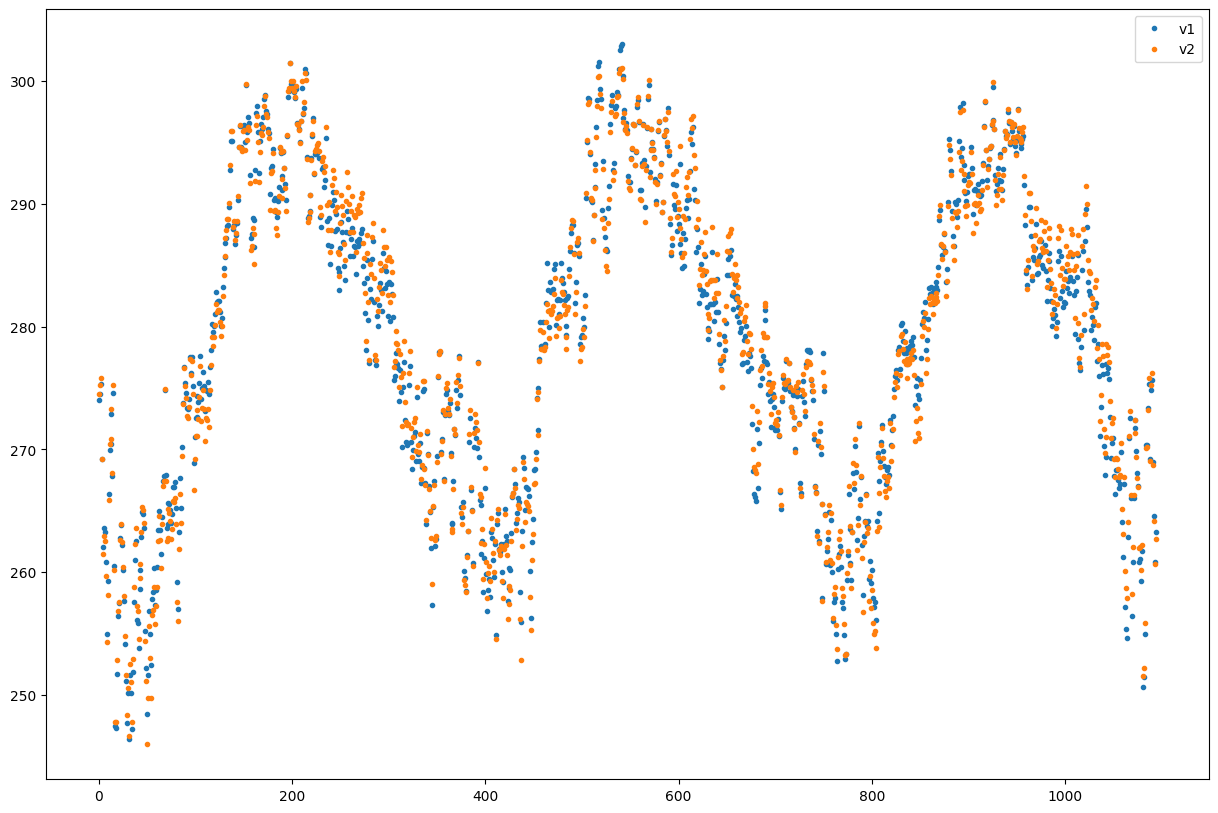

In [17]:
plt.figure(figsize=(15, 10))
plt.plot(output_windowed[-365 * 3 :, xind, yind], ".", label="v1")
plt.plot(output_not_windowed[-365 * 3 :, xind, yind], ".", label="v2")
plt.legend()

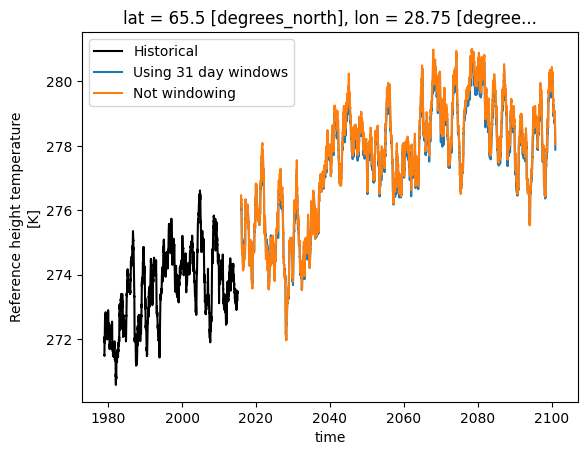

In [19]:
(dict_all_windowed["model_hist"][:, xind, yind].rolling(time=365).mean()).plot(
    label="Historical", color="k"
)
(output_windowed[:, xind, yind].rolling(time=365).mean()).plot(label="Using 31 day windows")
(output_not_windowed[:, xind, yind].rolling(time=365).mean()).plot(label="Not windowing")
plt.legend()

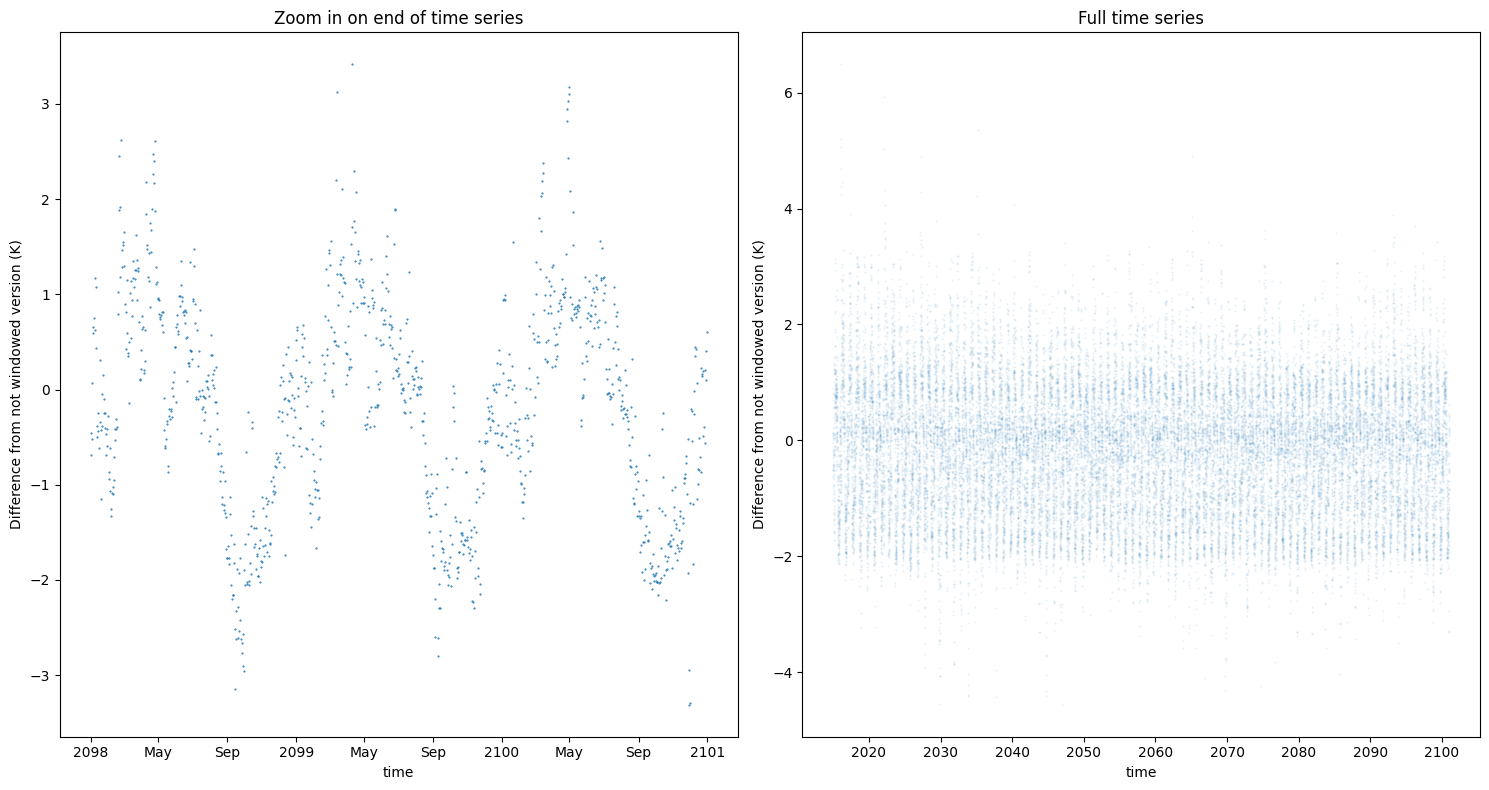

In [22]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
(output_windowed[-365 * 3 :, xind, yind] - output_not_windowed[-365 * 3 :, xind, yind]).plot(
    marker=".", linewidth=0, alpha=1, markersize=1
)
plt.ylabel("Difference from not windowed version (K)")
plt.title("Zoom in on end of time series")

plt.subplot(1, 2, 2)
(output_windowed[:, xind, yind] - output_not_windowed[:, xind, yind]).plot(
    marker=".", linewidth=0, alpha=0.1, markersize=1
)
plt.ylabel("Difference from not windowed version (K)")
plt.title("Full time series")
plt.tight_layout()

In [21]:
print("Max effect of detrending on any single day at any location")
print(np.nanmax(output_windowed - output_not_windowed))
print(np.nanmin(output_windowed - output_not_windowed))

Max effect of detrending on any single day
9.362015
-9.669617
